# RL Vocabulary Recommender
Reinforcement learning agent to recommend words based on user level and history. Uses a small mock dataset to keep the notebook self-contained.


*1. Setup and Imports*

In [51]:

import os
import math
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from pymongo import MongoClient
from dotenv import load_dotenv

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load MongoDB connection
load_dotenv()
mongo_uri = os.getenv("MONGO_URI")
if not mongo_uri:
    raise RuntimeError("MONGO_URI is required. Set it in .env file.")

print({
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "seed": SEED,
    "mongo_connected": bool(mongo_uri)
})

{'device': 'cpu', 'torch_version': '2.9.1+cpu', 'seed': 42, 'mongo_connected': True}


*2. Environment Definition for Vocabulary Recommendation*

In [52]:

@dataclass
class VocabEnvConfig:
    max_steps: int = 20
    alpha_reward: float = 1.0
    beta_gap: float = 0.5


def load_words_from_mongodb() -> pd.DataFrame:
    """Load words from MongoDB instead of mock data"""
    client = MongoClient(mongo_uri)
    try:
        db = client.get_default_database()
    except:
        db = client["test"]
    
    words = list(db["words"].find({}))
    
    if not words:
        raise ValueError("No words found in database. Please populate the 'words' collection.")
    
    # Convert to DataFrame
    words_df = pd.DataFrame([
        {
            "word": w.get("newari_word", ""),
            "difficulty": w.get("expertise_lvl", 3),
            "category": w.get("category", "general"),
            "_id": str(w.get("_id"))
        }
        for w in words
    ])
    
    print(f"Loaded {len(words_df)} words from MongoDB")
    return words_df


def get_user_expertise_from_mongo(user_id: str) -> int:
    """Fetch user expertise level from MongoDB users collection"""
    client = MongoClient(mongo_uri)
    try:
        db = client.get_default_database()
    except:
        db = client["test"]
    
    from bson import ObjectId
    user = db["users"].find_one({"_id": ObjectId(user_id)})
    
    if not user:
        print(f"⚠ User {user_id} not found. Using default level 2")
        return 2
    
    expertise_lvl = user.get("expertise_lvl", 2)
    print(f"✓ User {user_id} expertise level: {expertise_lvl}")
    return int(expertise_lvl)


def get_user_recent_accuracy_from_results(user_id: str, limit: int = 10) -> float:
    """Calculate user's recent accuracy from results collection"""
    client = MongoClient(mongo_uri)
    try:
        db = client.get_default_database()
    except:
        db = client["test"]
    
    from bson import ObjectId
    
    # Fetch recent results for the user
    results = list(db["results"].find(
        {"userID": ObjectId(user_id)},
        {"isCorrect": 1, "createdDate": 1}
    ).sort("createdDate", -1).limit(limit))
    
    if not results:
        print(f"⚠ No results found for user {user_id}. Using default accuracy 0.5")
        return 0.5
    
    # Calculate accuracy
    correct_count = sum(1 for r in results if r.get("isCorrect", False))
    accuracy = correct_count / len(results)
    
    print(f"✓ User {user_id} recent accuracy: {accuracy:.2%} (from {len(results)} results)")
    return accuracy


class VocabEnv:
    """Lightweight env: state encodes user level + recent accuracy; action selects a word."""

    def __init__(self, words: pd.DataFrame, user_id: Optional[str] = None, user_level: Optional[int] = None, config: Optional[VocabEnvConfig] = None):
        """
        Initialize environment with user data from MongoDB
        
        Args:
            words: DataFrame of vocabulary words
            user_id: MongoDB user ID (fetches expertise_lvl and recent accuracy)
            user_level: Manual override for user level (if user_id not provided)
            config: Environment configuration
        """
        self.words = words.reset_index(drop=True)
        self.config = config or VocabEnvConfig()
        self.user_id = user_id
        
        # Fetch user data from MongoDB
        if user_id:
            self.user_level = get_user_expertise_from_mongo(user_id)
            self.initial_accuracy = get_user_recent_accuracy_from_results(user_id)
        else:
            self.user_level = user_level if user_level is not None else 2
            self.initial_accuracy = 0.5
            print(f"⚠ No user_id provided. Using manual level: {self.user_level}, accuracy: 0.5")
        
        self.step_count = 0
        self.history: List[Dict] = []
        self.state_dim = 3  # [user_level_norm, difficulty_gap_norm, recent_accuracy]

    def reset(self):
        self.step_count = 0
        self.history.clear()
        return self._state(np.random.randint(0, len(self.words)))

    def _state(self, action_idx: int) -> np.ndarray:
        difficulty = self.words.loc[action_idx, "difficulty"]
        difficulty_gap = difficulty - self.user_level
        
        # Use initial accuracy from MongoDB if no history yet
        recent_acc = np.mean([h["correct"] for h in self.history[-10:]]) if self.history else self.initial_accuracy
        
        user_level_norm = self.user_level / 5.0
        gap_norm = np.tanh(difficulty_gap / 3.0)
        return np.array([user_level_norm, gap_norm, recent_acc], dtype=np.float32)

    def step(self, action_idx: int) -> Tuple[np.ndarray, float, bool, Dict]:
        self.step_count += 1
        difficulty = self.words.loc[action_idx, "difficulty"]
        gap = difficulty - self.user_level
        # Simulated user correctness probability decreases with gap magnitude
        correct_prob = max(0.05, 0.9 - 0.15 * abs(gap))
        correct = np.random.rand() < correct_prob
        reward = self.config.alpha_reward * (1.0 if correct else 0.0) - self.config.beta_gap * abs(gap)
        self.history.append({"action": action_idx, "correct": float(correct), "gap": gap})
        done = self.step_count >= self.config.max_steps
        next_action = np.random.randint(0, len(self.words))
        next_state = self._state(next_action)
        info = {"correct": correct, "difficulty": difficulty, "gap": gap}
        return next_state, reward, done, info


# Load words from MongoDB
words_df = load_words_from_mongodb()

# Example: Create environment with a real user ID from your database
# Replace with actual user ID from your MongoDB users collection
# env = VocabEnv(words_df, user_id="675c57fd7f8ab437fcdbc64f")

# For training without specific user (uses random levels)
env = VocabEnv(words_df, user_level=2)
state = env.reset()
print("env state_dim", state.shape)


Loaded 1886 words from MongoDB
⚠ No user_id provided. Using manual level: 2, accuracy: 0.5
env state_dim (3,)


## Reward and State Representation
State: `[user_level_norm, difficulty_gap_norm, recent_accuracy]`.
Reward uses correctness and difficulty gap:
$$ r_t = \alpha \cdot \text{correct}_t - \beta \cdot |\text{difficulty\_gap}_t| $$
Defaults: $\alpha = 1.0$, $\beta = 0.5$. Recent accuracy is a simple moving average over last 10 interactions.


In [53]:
# 4. Policy Network (DQN style)
class DQN(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def select_action(q_net: DQN, state: np.ndarray, epsilon: float, action_dim: int) -> int:
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        q_values = q_net(s)
        return int(torch.argmax(q_values, dim=1).item())


action_dim = len(words_df)
q_net = DQN(state_dim=env.state_dim, action_dim=action_dim).to(DEVICE)
target_net = DQN(state_dim=env.state_dim, action_dim=action_dim).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())
optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [54]:
# 5. Experience Replay Buffer
@dataclass
class Transition:
    state: np.ndarray
    action: int
    reward: float
    next_state: np.ndarray
    done: bool


class ReplayBuffer:
    def __init__(self, capacity: int = 5000):
        self.capacity = capacity
        self.buffer: List[Transition] = []
        self.pos = 0

    def push(self, transition: Transition):
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.pos] = transition
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size: int) -> Transition:
        batch = random.sample(self.buffer, batch_size)
        states = torch.tensor(np.stack([b.state for b in batch]), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor([b.action for b in batch], dtype=torch.int64, device=DEVICE)
        rewards = torch.tensor([b.reward for b in batch], dtype=torch.float32, device=DEVICE)
        next_states = torch.tensor(np.stack([b.next_state for b in batch]), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor([b.done for b in batch], dtype=torch.float32, device=DEVICE)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


buffer = ReplayBuffer(capacity=2000)


In [55]:
# 6. Training Loop with Exploration
num_episodes = 30
gamma = 0.95
batch_size = 32
epsilon_start, epsilon_end, epsilon_decay = 0.9, 0.05, 0.97
target_update = 5

loss_log = []
reward_log = []

def optimize_model():
    if len(buffer) < batch_size:
        return None
    states, actions, rewards, next_states, dones = buffer.sample(batch_size)
    q_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_net(next_states).max(1)[0]
        target = rewards + gamma * next_q * (1 - dones)
    loss = loss_fn(q_values, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

for episode in range(num_episodes):
    state = env.reset()
    epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))
    ep_reward = 0.0

    for t in range(env.config.max_steps):
        action = select_action(q_net, state, epsilon, action_dim)
        next_state, reward, done, info = env.step(action)
        buffer.push(Transition(state, action, reward, next_state, done))
        loss_val = optimize_model()
        if loss_val is not None:
            loss_log.append(loss_val)
        ep_reward += reward
        state = next_state
        if done:
            break

    reward_log.append(ep_reward)
    if episode % target_update == 0:
        target_net.load_state_dict(q_net.state_dict())

print("training complete", {"episodes": num_episodes, "buffer": len(buffer)})


training complete {'episodes': 30, 'buffer': 600}


eval {'avg_reward': -2.4, 'avg_accuracy': 0.65}


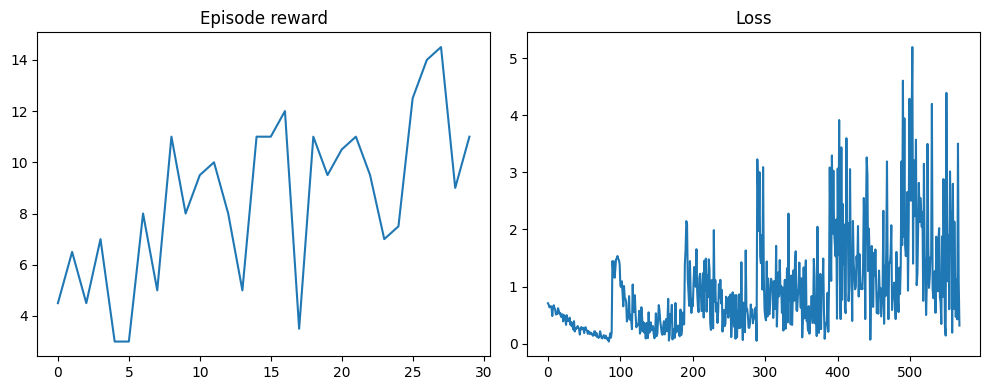

In [56]:
# 7. Evaluation and Metrics
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate(env: VocabEnv, episodes: int = 5):
    rewards = []
    accuracies = []
    for _ in range(episodes):
        state = env.reset()
        ep_rew = 0.0
        corrects = []
        for t in range(env.config.max_steps):
            action = select_action(q_net, state, epsilon=0.0, action_dim=action_dim)
            next_state, reward, done, info = env.step(action)
            ep_rew += reward
            corrects.append(1.0 if info["correct"] else 0.0)
            state = next_state
            if done:
                break
        rewards.append(ep_rew)
        accuracies.append(np.mean(corrects))
    return {
        "avg_reward": float(np.mean(rewards)),
        "avg_accuracy": float(np.mean(accuracies)),
    }

metrics = evaluate(env, episodes=5)
print("eval", metrics)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(reward_log)
plt.title("Episode reward")
plt.subplot(1,2,2)
plt.plot(loss_log)
plt.title("Loss")
plt.tight_layout()
plt.show()


In [57]:
# 8. Model Persistence
from pathlib import Path

# Save checkpoint in parent directory (ml_agent/checkpoints)
CKPT_DIR = Path("..") / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / "dqn_vocab.pt"


def save_checkpoint():
    torch.save({
        "q_net": q_net.state_dict(),
        "target_net": target_net.state_dict(),
        "optimizer": optimizer.state_dict(),
    }, CKPT_PATH)
    print(f"saved {CKPT_PATH}")


def load_checkpoint():
    if CKPT_PATH.exists():
        data = torch.load(CKPT_PATH, map_location=DEVICE)
        q_net.load_state_dict(data["q_net"])
        target_net.load_state_dict(data["target_net"])
        optimizer.load_state_dict(data["optimizer"])
        print(f"loaded {CKPT_PATH}")
    else:
        print("no checkpoint found")

save_checkpoint()
load_checkpoint()


saved ..\checkpoints\dqn_vocab.pt
loaded ..\checkpoints\dqn_vocab.pt


In [58]:
# 9. Unit Tests for Core Components
import unittest

class TestEnv(unittest.TestCase):
    def test_reset(self):
        s = env.reset()
        self.assertEqual(s.shape[0], env.state_dim)

    def test_step(self):
        s = env.reset()
        next_s, r, done, info = env.step(0)
        self.assertEqual(next_s.shape[0], env.state_dim)
        self.assertIsInstance(r, float)
        self.assertIn("correct", info)

class TestReplayBuffer(unittest.TestCase):
    def test_push_sample(self):
        buffer_local = ReplayBuffer(capacity=10)
        for _ in range(5):
            buffer_local.push(Transition(np.zeros(env.state_dim), 0, 0.0, np.zeros(env.state_dim), False))
        self.assertEqual(len(buffer_local), 5)

class TestModel(unittest.TestCase):
    def test_forward_shape(self):
        x = torch.zeros(2, env.state_dim)
        out = q_net(x)
        self.assertEqual(out.shape, (2, action_dim))

suite = unittest.TestLoader().loadTestsFromTestCase(TestEnv)
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestReplayBuffer))
suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestModel))
res = unittest.TextTestRunner(verbosity=2).run(suite)
print("tests run", res.testsRun)


test_reset (__main__.TestEnv.test_reset) ... ok
test_step (__main__.TestEnv.test_step) ... ok
test_push_sample (__main__.TestReplayBuffer.test_push_sample) ... ok
test_forward_shape (__main__.TestModel.test_forward_shape) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.011s

OK


tests run 4


In [59]:
# ============================================
# RECOMMENDATION FUNCTION WITH REAL USER DATA
# ============================================

def recommend_word_for_user(user_id: str, q_net: DQN, words_df: pd.DataFrame, epsilon: float = 0.0) -> Dict:
    """
    Get word recommendation for a specific user using MongoDB data
    
    Args:
        user_id: MongoDB user ID
        q_net: Trained DQN model
        words_df: DataFrame of vocabulary words
        epsilon: Exploration rate (0.0 for pure exploitation)
    
    Returns:
        Dict with recommended word and metadata
    """
    # Create environment with real user data
    env = VocabEnv(words_df, user_id=user_id)
    state = env.reset()
    
    # Get action (word index)
    action_dim = len(words_df)
    action_idx = select_action(q_net, state, epsilon, action_dim)
    
    # Get word details
    recommended_word = words_df.iloc[action_idx]
    
    # Calculate Q-value for this recommendation
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        q_values = q_net(s).cpu().numpy()[0]
        q_value = q_values[action_idx]
    
    return {
        "word_id": recommended_word["_id"],
        "word": recommended_word["word"],
        "difficulty": int(recommended_word["difficulty"]),
        "category": recommended_word["category"],
        "user_level": env.user_level,
        "user_recent_accuracy": env.initial_accuracy,
        "difficulty_gap": int(recommended_word["difficulty"]) - env.user_level,
        "q_value": float(q_value),
        "state": state.tolist()
    }


# ============================================
# TEST WITH REAL USER
# ============================================
print("\n" + "="*60)
print("TESTING WITH REAL USER FROM DATABASE")
print("="*60)

# Get a sample user ID from database
client = MongoClient(mongo_uri)
try:
    db = client.get_default_database()
except:
    db = client["test"]

sample_user = db["users"].find_one({})
if sample_user:
    user_id = str(sample_user["_id"])
    print(f"\n📝 Testing with user: {user_id}")
    print(f"Username: {sample_user.get('username', 'N/A')}")
    print(f"Expertise Level: {sample_user.get('expertise_lvl', 'N/A')}")
    
    # Get recommendation
    recommendation = recommend_word_for_user(user_id, q_net, words_df, epsilon=0.0)
    
    print(f"\n🎯 RECOMMENDATION:")
    print(f"  Word: {recommendation['word']}")
    print(f"  Difficulty: {recommendation['difficulty']}")
    print(f"  Category: {recommendation['category']}")
    print(f"  User Level: {recommendation['user_level']}")
    print(f"  Recent Accuracy: {recommendation['user_recent_accuracy']:.2%}")
    print(f"  Difficulty Gap: {recommendation['difficulty_gap']:+d}")
    print(f"  Q-Value: {recommendation['q_value']:.4f}")
    
    # Get multiple recommendations
    print(f"\n📚 TOP 5 RECOMMENDATIONS:")
    for i in range(5):
        rec = recommend_word_for_user(user_id, q_net, words_df, epsilon=0.1)
        print(f"{i+1}. {rec['word']} (Lvl {rec['difficulty']}, Gap: {rec['difficulty_gap']:+d})")
else:
    print("⚠ No users found in database")

print("\n" + "="*60)



TESTING WITH REAL USER FROM DATABASE

📝 Testing with user: 68dbf57dd1910e40a67e1ff6
Username: N/A
Expertise Level: 0
✓ User 68dbf57dd1910e40a67e1ff6 expertise level: 0
⚠ No results found for user 68dbf57dd1910e40a67e1ff6. Using default accuracy 0.5

🎯 RECOMMENDATION:
  Word: सुनानं
  Difficulty: 2
  Category: hospitality
  User Level: 0
  Recent Accuracy: 50.00%
  Difficulty Gap: +2
  Q-Value: 5.9390

📚 TOP 5 RECOMMENDATIONS:
✓ User 68dbf57dd1910e40a67e1ff6 expertise level: 0
⚠ No results found for user 68dbf57dd1910e40a67e1ff6. Using default accuracy 0.5
1. फछिम्फत्तले (Lvl 2, Gap: +2)
✓ User 68dbf57dd1910e40a67e1ff6 expertise level: 0
⚠ No results found for user 68dbf57dd1910e40a67e1ff6. Using default accuracy 0.5
2. सुनानं (Lvl 2, Gap: +2)
✓ User 68dbf57dd1910e40a67e1ff6 expertise level: 0
⚠ No results found for user 68dbf57dd1910e40a67e1ff6. Using default accuracy 0.5
3. फछिम्फत्तले (Lvl 2, Gap: +2)
✓ User 68dbf57dd1910e40a67e1ff6 expertise level: 0
⚠ No results found for user 68d